In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from decimal import Decimal

plt.style.use('dark_background')
pd.set_option("display.precision", 2)

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes_residencedata.csv')

# Some basic data preprocessing steps
df = df.drop(['X', 'trip','value','long_o', 'lat_o', 'long_d.x', 
              'lat_d.x', 'pincode', 'address','Prefecture', 'City', 
              'Town','lat_d.return','long_d.return', 'dest_inside'], axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

# Replacing 'pub' with 'train' in `mode` column.
selected_mode = df['mode'].to_numpy()
df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)

df.head()

,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,cardistance,...,INCOME,recco,information,incentivezone,task,job_type,income_con,address_inside,nearest_bus_dist,nearest_train_dist
0,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,15.17,...,4,2,only enviro,0,1,company employee,9000000,False,114.48,164.62
1,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,12.86,...,4,2,only enviro,0,2,company employee,9000000,False,114.48,164.62
2,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,15.17,...,4,1,no info,0,3,company employee,9000000,False,114.48,164.62
3,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,11.85,...,4,1,no info,0,4,company employee,9000000,False,114.48,164.62
4,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,15.17,...,4,1,no info,0,5,company employee,9000000,False,114.48,164.62


In [4]:
purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

attitudinal_variables = [x for x in df.columns if bool(re.search(r'\d', x))]
ohe_generic_variables = dict()

# <ins><b>Data Preprocessing</b></ins>

In [5]:
df['walkavail'] = np.where(df['mode']=='walk', 1, np.where(df['cardistance']<=7, 1, 0))

In [6]:
df['busincentive'] = np.where(df['incentivezone']==1, df['busincentive'], 0)
df['carincentive'] = np.where(df['incentivezone']==1, df['carincentive'], 0)
df['trainincentive'] = np.where(df['incentivezone']==1, df['trainincentive'], 0)
df['bikeincentive'] = np.where(df['incentivezone']==1, df['bikeincentive'], 0)
df['walkincentive'] = np.where(df['incentivezone']==1, df['walkincentive'], 0)
df['motorincentive'] = np.where(df['incentivezone']==1, df['motorincentive'], 0)


## Feature Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [8]:
ohe = OneHotEncoder()

In [9]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

In [10]:
df['high_income'] = np.where(df['INCOME'] >= 5, 1, 0)

# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)
job_type_df = job_type_df.drop(job_type_df.columns[0], axis=1)
ohe_generic_variables['jobs'] = list(job_type_df.columns)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])
info_df = info_df.drop(info_df.columns[0], axis=1)
ohe_generic_variables['info'] = list(info_df.columns)

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])
SEX_df = SEX_df.drop(SEX_df.columns[0], axis=1)

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)
Purpose_df = Purpose_df.drop('Purpose_999', axis=1)
ohe_generic_variables['purposes'] = list(Purpose_df.columns)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)
dep_time_zones_df = dep_time_zones_df.drop('Night_departure', axis=1)
ohe_generic_variables['departures'] = list(dep_time_zones_df.columns)

In [11]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Part time job,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


<AxesSubplot:>

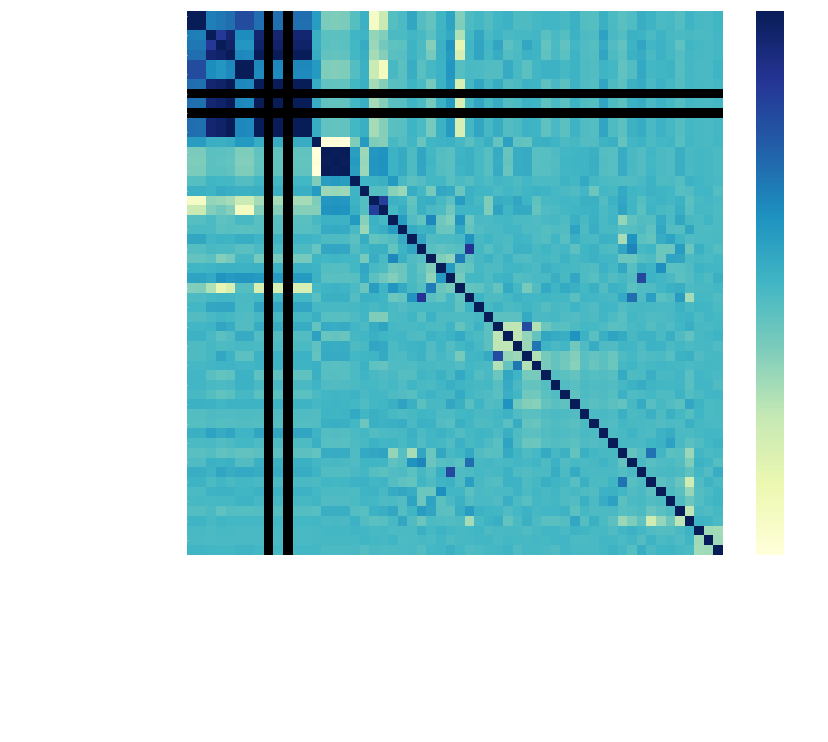

In [12]:
# all the alternative specific variables are heavily correlated with each other

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.heatmap(df2.drop(attitudinal_variables, axis='columns').corr(numeric_only=True), cmap='YlGnBu', annot=False, ax=ax)

## Train and Test Split

In [13]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import StandardScaler

In [14]:
USE_INSIDE_TO_TRAIN = False

def get_train_test_data(df, random_split=True, val_split=False, drop_att_vars=True, apply_smote=False, apply_tomek_links=False, 
                        apply_standardization=False, cols_to_standardize=[]):
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
        
    if random_split:
        train_df, test_df = train_test_split(df, test_size=0.1, random_state=500)
    else:
        train_df = df2.loc[df2['address_inside'] == USE_INSIDE_TO_TRAIN]
        test_df = df2.loc[df2['address_inside'] != USE_INSIDE_TO_TRAIN]
    
    if val_split:
        test_df, val_df = train_test_split(test_df, test_size=0.3, random_state=500)
    
    label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
    
    y_train = np.array([label_mapping_dict[label] for label in train_df['mode']])
    X_train = train_df.drop('mode', axis='columns')
    y_test = np.array([label_mapping_dict[label] for label in test_df['mode']])
    X_test = test_df.drop('mode', axis='columns')
    if val_split:
        y_val = np.array([label_mapping_dict[label] for label in val_df['mode']])
        X_val = val_df.drop('mode', axis='columns')
    
    if apply_smote:
        smote = SMOTE(random_state=500)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        X_test, y_test = smote.fit_resample(X_test, y_test)
        if val_split:
            X_val, y_val = smote.fit_resample(X_val, y_val)
    
    if apply_tomek_links:
        tomek = TomekLinks()
        X_train, y_train = tomek.fit_resample(X_train, y_train)
        X_test, y_test = tomek.fit_resample(X_test, y_test)
        if val_split:
            X_val, y_val = tomek.fit_resample(X_val, y_val)
    
    if apply_standardization:
        ss =  StandardScaler()
        X_train_scaled_arr = ss.fit_transform(X_train[cols_to_standardize])
        X_test_scaled_arr = ss.transform(X_test[cols_to_standardize])
        X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=cols_to_standardize)
        X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=cols_to_standardize)
        X_train_scaled.set_index(X_train.index, inplace=True)
        X_test_scaled.set_index(X_test.index, inplace=True)
        X_train.iloc[0:X_train.shape[0], X_train.columns.get_indexer(cols_to_standardize)] = X_train_scaled
        X_test.iloc[0:X_test.shape[0], X_test.columns.get_indexer(cols_to_standardize)] = X_test_scaled
        
        if val_split:
            X_val_scaled_arr = ss.fit_transform(X_val[cols_to_standardize])
            X_val_scaled = pd.DataFrame(X_val_scaled_arr, columns=cols_to_standardize)
            X_val_scaled.set_index(X_val.index, inplace=True)
            X_val.iloc[0:X_val.shape[0], X_val.columns.get_indexer(cols_to_standardize)] = X_val_scaled
    
    if val_split:
        return ((X_train, y_train), (X_val, y_val), (X_test, y_test)), label_mapping_dict
        
    return ((X_train, y_train), (X_test, y_test)), label_mapping_dict

In [15]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walkcost', 'walktime', 'walkincentive'],
    'bike': [ 'bikecost', 'biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'walk': 'walkavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

In [16]:
cols_to_standardize = ['AGE', 'nearest_bus_dist', 'nearest_train_dist']
for category in output_categories:
    cols_to_standardize.extend(asc_variable_names[category])

In [17]:
((X_train, y_train), (X_val, y_val), (X_test, y_test)), label_mapping_dict = get_train_test_data(df2, drop_att_vars=True,
                                                                random_split=False,
                                                                val_split=True,
                                                                apply_smote=False,
                                                                apply_tomek_links=False,
                                                                apply_standardization=False, 
                                                                cols_to_standardize=cols_to_standardize)
label_mapping_dict

{'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}

In [257]:
def get_uniques(x):
    x = x.dropna()
    val_counts = x.value_counts()
    print(val_counts.min())
    return val_counts/val_counts.min()
pd.concat([pd.Series(y_train), pd.Series(y_val), pd.Series(y_test)], axis=1).apply(get_uniques)

40
21
42


,0,1,2
1.0,2.58,1.10,1.00
2.0,32.45,10.48,11.19
3.0,4.65,1.00,1.43
4.0,3.77,1.24,2.55
5.0,1.82,2.57,2.90
6.0,1.00,1.29,1.50


In [18]:
X_test.shape, X_train.shape, X_val.shape

((864, 124), (1851, 124), (371, 124))

In [19]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)
    return list(X_train.drop(asc_variables_list, axis=1, errors='ignore').drop(
        avail_variable_names.values(), axis=1, errors='ignore').columns)

In [20]:
generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)
for item in ['cardistance', 'trip_duration']:
    if item in generic_variable_names:
        generic_variable_names.remove(item)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_train.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_train.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_train.columns.get_indexer(generic_variable_names)))

# <ins><b>Model Formulation</b></ins>

In [21]:
import tensorflow as tf
import tensorflow_probability as tfp
import keras_tuner

import functools
import contextlib
import time

tf.get_logger().setLevel('INFO')

In [22]:
# Helper functions

def make_val_and_grad_fn(value_fn):
    @functools.wraps(value_fn)
    def val_and_grad(x):
        return tfp.math.value_and_gradient(value_fn, x)
    return val_and_grad

@contextlib.contextmanager
def timed_execution():
    t0 = time.time()
    yield
    dt = time.time() - t0
    print('Evaluation took: %f seconds' % dt)


def np_value(tensor):
    """Get numpy value out of possibly nested tuple of tensors."""
    if isinstance(tensor, tuple):
        return type(tensor)(*(np_value(t) for t in tensor))
    else:
        return tensor.numpy()

def run(optimizer):
    """Run an optimizer and measure it's evaluation time."""
    optimizer()
    with timed_execution():
        result = optimizer()
    return np_value(result)

In [23]:
def generate_avail_data(X):
    avail_vals = []
    for cat in output_categories:
        if cat in avail_variable_names:
            avail_vals.append(X[avail_variable_names[cat]].to_numpy())
        else:
            avail_vals.append(np.ones((X.shape[0]), dtype='int64'))
    avail_vals = np.vstack(avail_vals)
    avail_vals = tf.cast(avail_vals, dtype='float32')
    return avail_vals

In [24]:
def create_alt_spec_params(alternatives, name):
    """
    alternatives (list of str): Names of various corresponding to which this variable should be created.
    name (str): The name of this variable.
    """
    alt_spec_vars = []
    if name == 'nearest_bus_dist':
        alternative='bus'
        alt_spec_var = tf.Variable(tf.zeros([1,]), dtype='float32', 
                        name=f'{name}_{alternative}', trainable=True)
        alt_spec_vars.append(alt_spec_var)
        
    elif name == 'nearest_train_dist':
        alternative='train'
        alt_spec_var = tf.Variable(tf.zeros([1,]), dtype='float32', 
                        name=f'{name}_{alternative}', trainable=True)
        alt_spec_vars.append(alt_spec_var)
        
    else:
        for alternative in alternatives:
            alt_spec_var = tf.Variable(tf.zeros([1,]), dtype='float32', 
                            name=f'{name}_{alternative}', trainable=True)
            alt_spec_vars.append(alt_spec_var)
    return alt_spec_vars

In [25]:
def initiate_params(alt_spec_vars=True, ind_spec_vars_list=None):
    model_params = []
    
    if alt_spec_vars:
        # Generic parameters for alternative specific variables of travelcost, traveltime, travelincentive
        gen_tc = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='travelcost', trainable=True)
        gen_tt = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='traveltime', trainable=True)
        gen_ti = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='travelincentive', trainable=True)
        model_params.extend([gen_tc, gen_tt, gen_ti])

        # Alternative specific constants for bus, train, walk, bike, motor
        asc_bus = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='bus_constant', trainable=True)
        asc_train = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='train_constant', trainable=True)
        asc_walk = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='walk_constant', trainable=True)
        asc_bike = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='bike_constant', trainable=True)
        asc_motor = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='motor_constant', trainable=True)
        model_params.extend([asc_bus, asc_train, asc_walk, asc_bike, asc_motor])
    
    if ind_spec_vars_list is not None:
        alternatives = ['bus', 'train', 'walk', 'bike', 'motor']
        for var in ind_spec_vars_list:
            isv_asp_params = create_alt_spec_params(alternatives, var)
            model_params.extend(isv_asp_params)
    
    return model_params


In [55]:
def utilities(x_name, x_val, params, alt_spec_vars=True, ind_spec_vars_list=None):
    x_val = tf.convert_to_tensor(x_val, dtype='float32')
    ntrips = x_val.shape[-1]
    X = dict()
    x_val_trans = tf.transpose(x_val)
    for i, name in enumerate(x_name):
        val = x_val_trans[i]
        X[name] = val

#     if alt_spec_vars:
#         gen_tc, gen_tt, gen_ti = params[:3]
#         asc_bus, asc_train, asc_walk, asc_bike, asc_motor = params[3:8]
            
    if alt_spec_vars:
        # Contribution to utility from tc, tt, ti
        travel_util_bus = X['buscost'] * params[0] + X['bustime'] * params[1] + X['busincentive'] * params[2] + params[3]
        travel_util_train = X['traincost'] * params[0] + X['traintime'] * params[1] + X['trainincentive'] * params[2] + params[4]
        travel_util_walk = X['walktime'] * params[1] + X['walkincentive'] * params[2] + params[5]  # walkcost is 0
        travel_util_bike = X['biketime'] * params[1] + X['bikeincentive'] * params[2] + params[6]  # bikecost is 0
        travel_util_motor = X['motorcost'] * params[0] + X['motortime'] * params[1] + X['motorincentive'] * params[2] + params[7]
        travel_util_car = X['carcost'] * params[0] + X['cartime'] * params[1] + X['carincentive'] * params[2]

        utility_bus = travel_util_bus
        utility_car = travel_util_car
        utility_train = travel_util_train
        utility_walk = travel_util_walk
        utility_bike = travel_util_bike
        utility_motor = travel_util_motor

    if ind_spec_vars_list is not None:
        nparams = params.shape[0]
        param_count = 0
        var_count = 0
        for i in range(8, nparams):
            isv_asp_param = params[i]
            var_name = ind_spec_vars_list[var_count]
            isv_util = X[var_name] * isv_asp_param
            
            if var_name == 'nearest_bus_dist':
                utility_bus += isv_util
                var_count += 1
                
            elif var_name == 'nearest_train_dist':
                utility_train += isv_util
                var_count += 1
        
            else:
                utility_bus += tf.where(tf.equal(param_count, 0), isv_util, 0.0)
                utility_train += tf.where(tf.equal(param_count, 1), isv_util, 0.0)
                utility_walk += tf.where(tf.equal(param_count, 2), isv_util, 0.0)
                utility_bike += tf.where(tf.equal(param_count, 3), isv_util, 0.0)
                utility_motor += tf.where(tf.equal(param_count, 4), isv_util, 0.0)
                
                param_count += 1
                param_count = param_count % 5
                if param_count == 0:
                    var_count += 1

    return tf.transpose(tf.stack((utility_bus, utility_car, utility_train, utility_walk, utility_bike, utility_motor)))


In [56]:
def loss(true_y, utilities, avail_vals):
    initial_probs = tf.nn.softmax(utilities)
    masked_probs = initial_probs*tf.transpose(avail_vals)
    final_probs = tf.divide(masked_probs, 
                            tf.reshape((tf.reduce_sum(masked_probs, axis=-1) + tf.keras.backend.epsilon()), 
                                       [-1, 1])
                           )
    ce_loss = -tf.reduce_mean(tf.reduce_sum(true_y*tf.math.log(
        final_probs + tf.keras.backend.epsilon()), axis=-1))
    return ce_loss

In [57]:
def apply_regularization(loss, params, l1_lambda=0.001, l2_lambda=0.001):
    # Applying l2 penalty on parameters of alternative specific variables
    l2_penalty = l2_lambda*tf.reduce_sum(tf.math.square(params[:3]))
    
    # Applying l1 penalty on paramters of individual specific variables
    l1_penalty = l1_lambda*tf.reduce_sum(tf.math.abs(params[8:]))
    
    return loss + l1_penalty + l2_penalty

In [58]:
def predict(x_name, x_val, params, avail_vals, alt_spec_vars=True, ind_spec_vars_list=None):
    """
    Returns the final probabilites and mode predictions
    """
    utils = utilities(x_name, x_val, params, alt_spec_vars=True, ind_spec_vars_list=ind_spec_vars_list)
    initial_probs = tf.nn.softmax(utils)
    masked_probs = initial_probs*tf.transpose(avail_vals)
    final_probs = tf.divide(masked_probs, 
                            tf.reshape((tf.reduce_sum(masked_probs, axis=-1) + tf.keras.backend.epsilon()), 
                                       [-1, 1])
                           )
    
    return final_probs, tf.argmax(final_probs, axis=1)

## Training with BFGS optimizer

In [209]:
ind_spec_vars = ['AGE', 'Female', 'high_income', 'nearest_bus_dist', 'nearest_train_dist',]
#                  'Early_morning_departure','AM_peak_departure', 'Off_peak_departure', 
#                  'PM_peak_departure','Purpose_101', 'Purpose_998', 'Purpose_100', 
#                  'Purpose_300', 'Purpose_200', 'Purpose_400', 'Purpose_600', 
#                  'Purpose_500', 'Purpose_202', 'Purpose_201', 'Female', 
#                  'job_type_Part time job', 'job_type_Management executive', 
#                  'job_type_civil servant', 'job_type_Housewife', asdsad
#                  'job_type_Self employed/ Freelance', 'job_type_Others', 
#                  'job_type_Unemployed']
ind_spec_vars = None
params = initiate_params(ind_spec_vars_list=ind_spec_vars)
ohe_true_y = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_train)
x_names = X_train.columns
x_vals = X_train.values

l1_lambda = 0
l2_lambda = 1000

In [210]:
@make_val_and_grad_fn
def loss_val_nd_loss_grad(params):
    curr_utils = utilities(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars)
    curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
    penalty_loss = apply_regularization(curr_loss, params, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    return penalty_loss

In [211]:
@tf.function
def mnl_with_bfgs():
    return tfp.optimizer.bfgs_minimize(loss_val_nd_loss_grad, 
                                       initial_position=tf.reshape(params, shape=[-1]),
                                      tolerance=1e-8,
                                      max_iterations=500)

In [212]:
%%time
results = run(mnl_with_bfgs)

print('BFGS Results')
print('Converged:', results.converged)
print('Location of the minimum:', results.position)
print('Number of iterations:', results.num_iterations)

Evaluation took: 0.373238 seconds
BFGS Results
Converged: True
Location of the minimum: [-5.8119331e-04 -1.0768782e-03  3.0005570e-03 -2.2610040e+00
 -1.8763591e+00 -1.4102983e+00 -1.1132550e+00 -9.2200756e-01]
Number of iterations: 23
Wall time: 39.5 s


## <ins><b>Model Evaluation</b></ins>

In [213]:
from sklearn.metrics import confusion_matrix, classification_report, fbeta_score

### Baseline model
Predicting only the car mode

In [233]:
y_pred_base_train = np.ones(X_train.shape[0])*2
y_pred_base_test = np.ones(X_test.shape[0])*2
y_pred_base_val = np.ones(X_val.shape[0])*2

f2_base_train = fbeta_score(y_train, y_pred_base_train, beta=2, average='macro')
f2_base_test = fbeta_score(y_test, y_pred_base_test, beta=2, average='macro')
f2_base_val = fbeta_score(y_val, y_pred_base_val, beta=2, average='macro')


print("F2 Measure of baseline model on train data is {0:.2f}".format(f2_base_train))
print("F2 Measure of baseline model on test data is {0:.2f}".format(f2_base_test))
print("F2 Measure of baseline model on validation data is {0:.2f}".format(f2_base_val))


F2 Measure of baseline model on train data is 0.15
F2 Measure of baseline model on test data is 0.14
F2 Measure of baseline model on validation data is 0.15


### Training data results

In [214]:
y_pred_train = predict(X_train.columns, X_train.values, results.position, 
                 avail_vals, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1

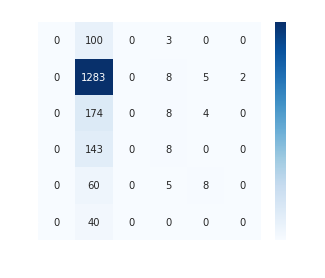

In [215]:
cm = confusion_matrix(y_train, y_pred_train)
cm_df = pd.DataFrame(cm, index=output_categories, columns=output_categories)

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [216]:
f2_train = fbeta_score(y_train, y_pred_train, beta=2, average='macro')
print(classification_report(y_train, y_pred_train, target_names=output_categories, zero_division=0))
print("F2 Measure is {0:.2f}".format(f2_train))

              precision    recall  f1-score   support

         bus       0.00      0.00      0.00       103
         car       0.71      0.99      0.83      1298
       train       0.00      0.00      0.00       186
        walk       0.25      0.05      0.09       151
        bike       0.47      0.11      0.18        73
       motor       0.00      0.00      0.00        40

    accuracy                           0.70      1851
   macro avg       0.24      0.19      0.18      1851
weighted avg       0.54      0.70      0.59      1851

F2 Measure is 0.18


Text(0.5, 0, 'Modes')

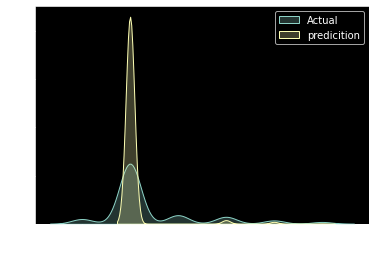

In [217]:
sns.kdeplot(y_train, fill=True, label='Actual')
sns.kdeplot(y_pred_train, fill=True, label='predicition')
plt.legend()
plt.xlabel('Modes')

### Testing data results

In [218]:
avail_vals_test = generate_avail_data(X_test)
y_pred_test = predict(X_test.columns, X_test.values, results.position, 
                 avail_vals_test, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1

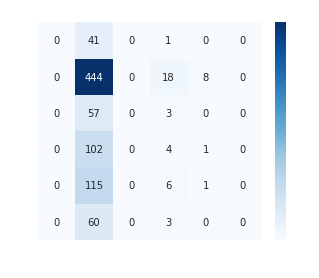

In [219]:
cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(cm, index=output_categories, columns=output_categories)

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [220]:
print(classification_report(y_test, y_pred_test, target_names=output_categories, zero_division=0))
f2_test = fbeta_score(y_test, y_pred_test, beta=2, average='macro')
print("F2 measure for test data is {0:.2f}".format(f2_test))

              precision    recall  f1-score   support

         bus       0.00      0.00      0.00        42
         car       0.54      0.94      0.69       470
       train       0.00      0.00      0.00        60
        walk       0.11      0.04      0.06       107
        bike       0.10      0.01      0.02       122
       motor       0.00      0.00      0.00        63

    accuracy                           0.52       864
   macro avg       0.13      0.17      0.13       864
weighted avg       0.32      0.52      0.38       864

F2 measure for test data is 0.15


<AxesSubplot:ylabel='Density'>

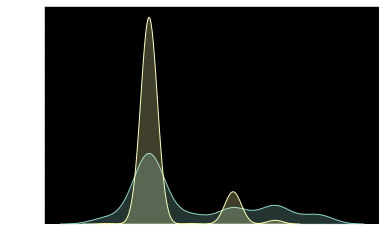

In [185]:
sns.kdeplot(y_test, fill=True)
sns.kdeplot(y_pred_test, fill=True)

## Errors and T-Ratios

In [186]:
std_errors = np.sqrt(np.diagonal(results.inverse_hessian_estimate))/np.sqrt(len(ohe_true_y))

In [187]:
t_ratios = results.position/std_errors

In [188]:
data_dict = {x.name.strip(':0'):[results.position[i], std_errors[i], t_ratios[i]] for i, x in enumerate(params)}
result_df = pd.DataFrame(data_dict).T
result_df.columns = ['estimate', 'std_errors', 't_ratios']
result_df

,estimate,std_errors,t_ratios
travelcost,-2.45e-03,2.54e-04,-9.65
traveltime,-5.64e-02,3.22e-03,-17.53
travelincentive,3.64e-03,3.33e-04,10.93
bus_constant,-5.28e-01,9.42e-02,-5.60
train_constant,-8.63e-01,8.57e-02,-10.07
walk_constant,1.20e-01,1.96e-02,6.14
bike_constant,-6.81e-01,7.34e-02,-9.27
motor_constant,-1.14e+00,1.24e-01,-9.21


## Negative log likelihood and other metrics

In [189]:
ohe_true_y = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_train)
x_names = X_train.columns
x_vals = X_train.values

initial_mean_negLL_train = loss_val_nd_loss_grad(tf.reshape(initiate_params(), shape=[-1]))[0].numpy()
final_mean_negLL_train = loss_val_nd_loss_grad(result_df['estimate'].to_numpy())[0].numpy()
AIC_train = 2*(len(result_df)+final_mean_negLL_train*len(df2))
print(f"Initial Training log loss: {-initial_mean_negLL_train*len(df2):.2f}")
print(f'Final Training log loss: {-final_mean_negLL_train*len(df2):.2f}')
print(f"Training AIC value: {AIC_train:.2f}")

print("**************************************************************")

ohe_true_y = tf.one_hot(y_test-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_test)
x_names = X_test.columns
x_vals = X_test.values

initial_mean_negLL_test = loss_val_nd_loss_grad(tf.reshape(initiate_params(), shape=[-1]))[0].numpy()
final_mean_negLL_test = loss_val_nd_loss_grad(result_df['estimate'].to_numpy())[0].numpy()
AIC_test = 2*(len(result_df)+final_mean_negLL_test*len(df2))
print(f"Initial Testing log loss: {-initial_mean_negLL_test*len(df2):.2f}")
print(f'Final Testing log loss: {-final_mean_negLL_test*len(df2):.2f}')
print(f"Testing AIC value: {AIC_test:.2f}")

Initial Training log loss: -3261.21
Final Training log loss: -2190.25
Training AIC value: 4396.49
**************************************************************
Initial Testing log loss: -3988.77
Final Testing log loss: -3189.44
Testing AIC value: 6394.88


In [190]:
classical_res = pd.read_csv('classical_model/MNL_2762023_estimates.csv')
classical_res.rename(columns={'Unnamed: 0':'variable'}, inplace=True)
classical_res['variable'] = ['asc_bike', 'asc_bus', 'asc_motor', 'asc_train', 'asc_walk', 'gen_tc', 'gen_tt', 'gen_ti']
classical_res

,variable,Estimate,Std.err.,t-ratio(0),Rob.std.err.,Rob.t-ratio(0)
0,asc_bike,-1.73e-01,8.56e-02,-2.02,2.45e-01,-0.71
1,asc_bus,-4.91e-01,1.58e-01,-3.11,4.07e-01,-1.21
2,asc_motor,-1.91e-01,1.15e-01,-1.66,4.19e-01,-0.45
3,asc_train,-7.26e-01,1.14e-01,-6.38,3.78e-01,-1.92
4,asc_walk,3.65e-02,1.12e-01,0.33,3.15e-01,0.12
5,gen_tc,-1.92e-03,3.28e-04,-5.87,7.71e-04,-2.50
6,gen_tt,-5.94e-02,3.64e-03,-16.31,1.44e-02,-4.12
7,gen_ti,1.95e-03,2.58e-04,7.57,5.79e-04,3.38


## <ins><b>Comparing Test and Train Fit</b></ins>

In [191]:
train_report = classification_report(y_train, y_pred_train, target_names=output_categories, zero_division=0, output_dict=True)
train_report['final_neg_log_loss'] = final_mean_negLL_train
train_report['f2-score']=f2_train

train_report.update(train_report['macro avg'])
to_rem = ['bus', 'car', 'train', 'walk', 'bike', 'motor', 'macro avg', 'weighted avg']
for val in to_rem:
    del train_report[val]
train_test_report = {'train': train_report}

In [192]:
test_report = classification_report(y_test, y_pred_test, target_names=output_categories, zero_division=0, output_dict=True)
test_report['final_neg_log_loss'] = final_mean_negLL_test
test_report['f2-score'] = f2_test

test_report.update(test_report['macro avg'])
for val in to_rem:
    del test_report[val]
train_test_report['test'] = test_report

In [193]:
final_report = pd.DataFrame.from_dict(train_test_report).drop(['f1-score', 'accuracy', 'precision', 'recall'], axis=0).rename(index={'support':'total_trips'})
final_report

,train,test
final_neg_log_loss,0.71,1.03
f2-score,0.29,0.21
total_trips,1851.00,864.00


In [194]:
def print_imbalance_ratio(y):
    distri = np.unique(y, return_counts=True)[1]
    low_cat = output_categories[distri.argmin()]; low_index = distri.argmin()
    high_cat = output_categories[distri.argmax()]; high_index = distri.argmax()
    data_ratios = np.round(distri/distri.min())
    print(f"data imbalance ratio in {high_cat} to {low_cat} is {int(data_ratios[high_index])}:{int(data_ratios[low_index])}")

In [195]:
print("Train ", end=""); print_imbalance_ratio(y_train)
print("Test ", end=''); print_imbalance_ratio(y_test)

Train data imbalance ratio in car to motor is 32:1
Test data imbalance ratio in car to bus is 11:1


## <b><ins>Model Logging</ins></b>

In [196]:
models = os.listdir('model_reports')
nmod = len(models)
dir_path = f'model_reports//model_{nmod+1}'
os.mkdir(dir_path)

result_df.to_csv(f'{dir_path}//params.csv')
final_report.to_csv(f"{dir_path}//report.csv")

preprocess_info = f"Trained on trips originating outside CBD.\nNo outlier removal.\nNo Standardization.\nNo smote.\nNo Tomek links.\n"
regularization_info = f'Parameters of Alternative specific variables under l2 penalty with lambda {l2_lambda}.\nParams of individual specific variables under l1 penalty with lambda {l1_lambda}.\n'
final_info = preprocess_info + regularization_info

with open(f'{dir_path}//info.txt', 'w') as f:
    f.write(final_info)
    f.close()